# Artificial Intelligence & Machine Learning — Task 1
## Build & Evaluate a Linear Regression Model (House Price Predictor)

**Organization:** Maincrafts Technology  
**Project:** California Housing Price Predictor  
**Author:** AI & Machine Learning Intern  
**Objective:** Introduce the complete Machine Learning workflow: data ingestion, exploratory data analysis (EDA), data preprocessing, model training (`LinearRegression`), performance evaluation (MAE, RMSE, $R^2$), residual diagnostics, and model serialization.

---
### Workflow Stages
1. **Setup & Data Ingestion**: Load the California Housing dataset from `sklearn.datasets`.
2. **Exploratory Data Analysis (EDA)**: Inspect distributions, missing values, statistics, and correlation patterns.
3. **Data Splitting**: Partition data into training (80%) and testing (20%) sets.
4. **Model Training**: Fit an Ordinary Least Squares (OLS) Linear Regression model.
5. **Evaluation**: Compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ score.
6. **Residual Diagnostics**: Analyze prediction errors, homoscedasticity, and coefficient weights.
7. **Model Persistence**: Serialize the trained model pipeline for production inference.
8. **Summary & Improvement Roadmap**: Document findings and non-linear model opportunities.


### 1. Imports & Global Configuration
We load standard data science and machine learning libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn`.

In [1]:
# Basics & Data Science Stack
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics & Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['font.sans-serif'] = 'Arial'
%matplotlib inline

print("All dependencies successfully imported!")


All dependencies successfully imported!


### 2. Dataset Loading & Inspection
We load the California Housing dataset using `fetch_california_housing(as_frame=True)`.  
The target variable is `MedHouseVal` (Median House Value in hundreds of thousands of dollars, i.e., $100,000s).

In [2]:
# Load California housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into a single pandas DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Dimensions: 20640 rows, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Feature Descriptions:
* **MedInc**: Median income in block group (in $10,000s).
* **HouseAge**: Median house age in block group (in years).
* **AveRooms**: Average number of rooms per household.
* **AveBedrms**: Average number of bedrooms per household.
* **Population**: Block group population.
* **AveOccup**: Average number of household members.
* **Latitude**: Block group latitude coordinate.
* **Longitude**: Block group longitude coordinate.
* **MedHouseVal (Target)**: Median house value for California districts (in $100,000s).


### 3. Data Hygiene & Missing Value Audit
Checking for missing values, null entries, and column data types.

In [3]:
# Check data types and missing values
null_counts = df.isnull().sum()
print("Missing values per feature:")
print(null_counts)
print(f"\nTotal missing values across entire dataset: {null_counts.sum()}")


Missing values per feature:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values across entire dataset: 0


In [4]:
# Summary statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### 4. Exploratory Data Analysis (EDA)
Understanding feature distributions, skewness, and the target variable behavior.

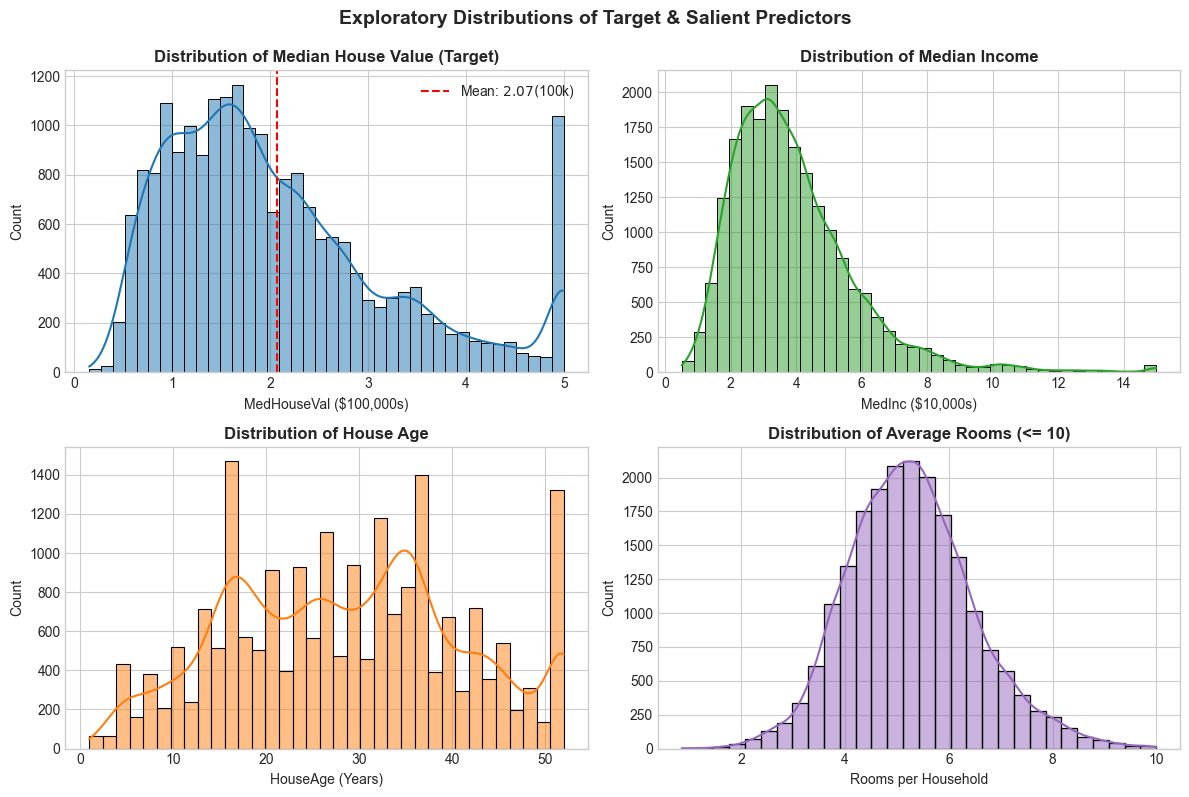

In [5]:
# Visualizing Target Variable (MedHouseVal) and Key Regressors
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. MedHouseVal
sns.histplot(df['MedHouseVal'], kde=True, color='#1f77b4', ax=axes[0, 0], bins=40)
axes[0, 0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Mean: ${df['MedHouseVal'].mean():.2f} ($100k)")
axes[0, 0].set_title("Distribution of Median House Value (Target)", fontweight='bold')
axes[0, 0].set_xlabel("MedHouseVal ($100,000s)")
axes[0, 0].legend()

# 2. MedInc
sns.histplot(df['MedInc'], kde=True, color='#2ca02c', ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Distribution of Median Income", fontweight='bold')
axes[0, 1].set_xlabel("MedInc ($10,000s)")

# 3. HouseAge
sns.histplot(df['HouseAge'], kde=True, color='#ff7f0e', ax=axes[1, 0], bins=35)
axes[1, 0].set_title("Distribution of House Age", fontweight='bold')
axes[1, 0].set_xlabel("HouseAge (Years)")

# 4. AveRooms (trimmed for visual clarity)
sns.histplot(df[df['AveRooms'] <= 10]['AveRooms'], kde=True, color='#9467bd', ax=axes[1, 1], bins=30)
axes[1, 1].set_title("Distribution of Average Rooms (<= 10)", fontweight='bold')
axes[1, 1].set_xlabel("Rooms per Household")

plt.suptitle("Exploratory Distributions of Target & Salient Predictors", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


#### Correlation Analysis
We calculate the Pearson correlation matrix to understand the linear relationships between features and the target variable.

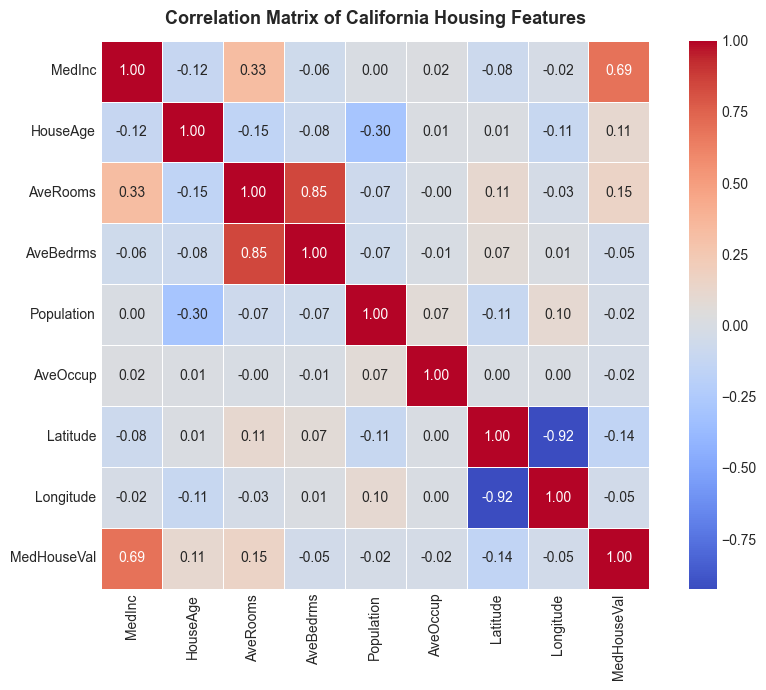

Correlations with Target (MedHouseVal) sorted by magnitude:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [6]:
# Correlation Matrix Heatmap
plt.figure(figsize=(9, 7))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            linewidths=0.5, square=True)
plt.title("Correlation Matrix of California Housing Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Correlations with Target (MedHouseVal) sorted by magnitude:")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))


#### Geographic Distribution
Visualizing house prices across geographic coordinates (Latitude vs Longitude).  
Coastal areas (e.g. San Francisco Bay Area and Los Angeles) exhibit noticeable price concentration.

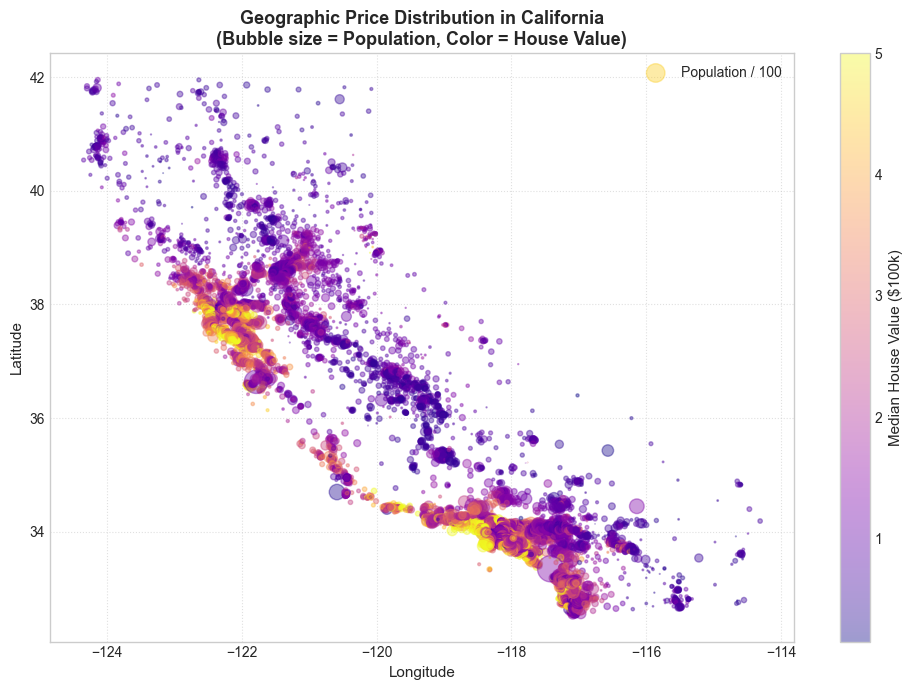

In [7]:
# California Geographic Price Scatter Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='plasma', alpha=0.4,
    s=df['Population'] / 100, label='Population / 100'
)
cbar = plt.colorbar(scatter)
cbar.set_label("Median House Value ($100k)", fontsize=11)
plt.xlabel("Longitude", fontsize=11)
plt.ylabel("Latitude", fontsize=11)
plt.title("Geographic Price Distribution in California\n(Bubble size = Population, Color = House Value)",
          fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 5. Feature Selection & Train/Test Split
We separate features $X$ and target $y$, followed by an 80/20 train/test split with `random_state=42` for exact reproducibility.

In [8]:
# Separate regressors (X) and target (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Perform 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set:    X_test={X_test.shape},  y_test={y_test.shape}")


Training set:   X_train=(16512, 8), y_train=(16512,)
Testing set:    X_test=(4128, 8),  y_test=(4128,)


### 6. Model Training (Linear Regression)
We instantiate and fit `LinearRegression()` using Ordinary Least Squares (OLS).

In [9]:
# Instantiate and train baseline Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

print("Model training completed successfully!")
print(f"Intercept (theta_0): {model.intercept_:.4f}")
print("\nLearned Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:12s}: {coef:12.6f}")


Model training completed successfully!
Intercept (theta_0): -37.0233

Learned Feature Coefficients:
  MedInc      :     0.448675
  HouseAge    :     0.009724
  AveRooms    :    -0.123323
  AveBedrms   :     0.783145
  Population  :    -0.000002
  AveOccup    :    -0.003526
  Latitude    :    -0.419792
  Longitude   :    -0.433708


### 7. Model Evaluation & Performance Metrics
We evaluate the model using standard regression metrics:
* **Mean Absolute Error (MAE)**: Average magnitude of the errors without direction.
* **Mean Squared Error (MSE)** & **Root Mean Squared Error (RMSE)**: Penalizes larger deviations more heavily.
* **$R^2$ Score (Coefficient of Determination)**: Proportion of variance in the target explained by the model.


In [10]:
# Compute regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, model.predict(X_train))

# Format and display results
print("=" * 50)
print("              MODEL PERFORMANCE SCORECARD")
print("=" * 50)
print(f"Mean Absolute Error (MAE)   : {mae:.4f} ($100k)  ->  ${mae*100000:,.2f}")
print(f"Mean Squared Error (MSE)    : {mse:.4f}")
print(f"Root Mean Squared Error(RMSE): {rmse:.4f} ($100k)  ->  ${rmse*100000:,.2f}")
print(f"R² Score (Test Set)         : {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"R² Score (Train Set)        : {r2_train:.4f} ({r2_train*100:.2f}%)")
print("=" * 50)


              MODEL PERFORMANCE SCORECARD
Mean Absolute Error (MAE)   : 0.5332 ($100k)  ->  $53,320.01
Mean Squared Error (MSE)    : 0.5559
Root Mean Squared Error(RMSE): 0.7456 ($100k)  ->  $74,558.14
R² Score (Test Set)         : 0.5758 (57.58%)
R² Score (Train Set)        : 0.6126 (61.26%)


### 8. Visual Diagnostics & Residual Analysis
We inspect:
1. **Actual vs Predicted Scatter Plot**: Shows how closely predictions align with the 45-degree reference line ($y=x$).
2. **Residual Distribution & Homoscedasticity**: Verifies whether errors have zero mean and consistent variance across predicted values.
3. **Standardized Feature Importance**: Compares feature impacts after normalising feature scales.


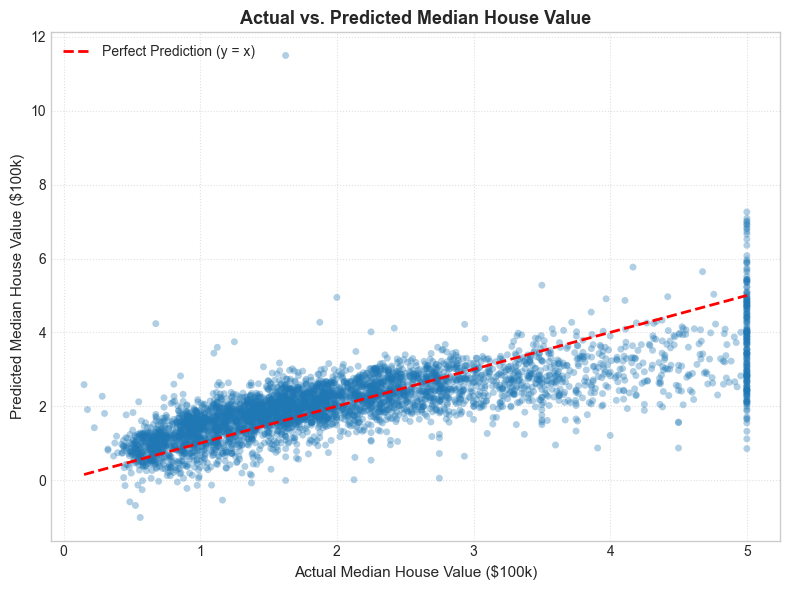

In [11]:
# 1. Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.35, color='#1f77b4', edgecolors='none', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y = x)')
plt.xlabel("Actual Median House Value ($100k)", fontsize=11)
plt.ylabel("Predicted Median House Value ($100k)", fontsize=11)
plt.title("Actual vs. Predicted Median House Value", fontsize=13, fontweight='bold')
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


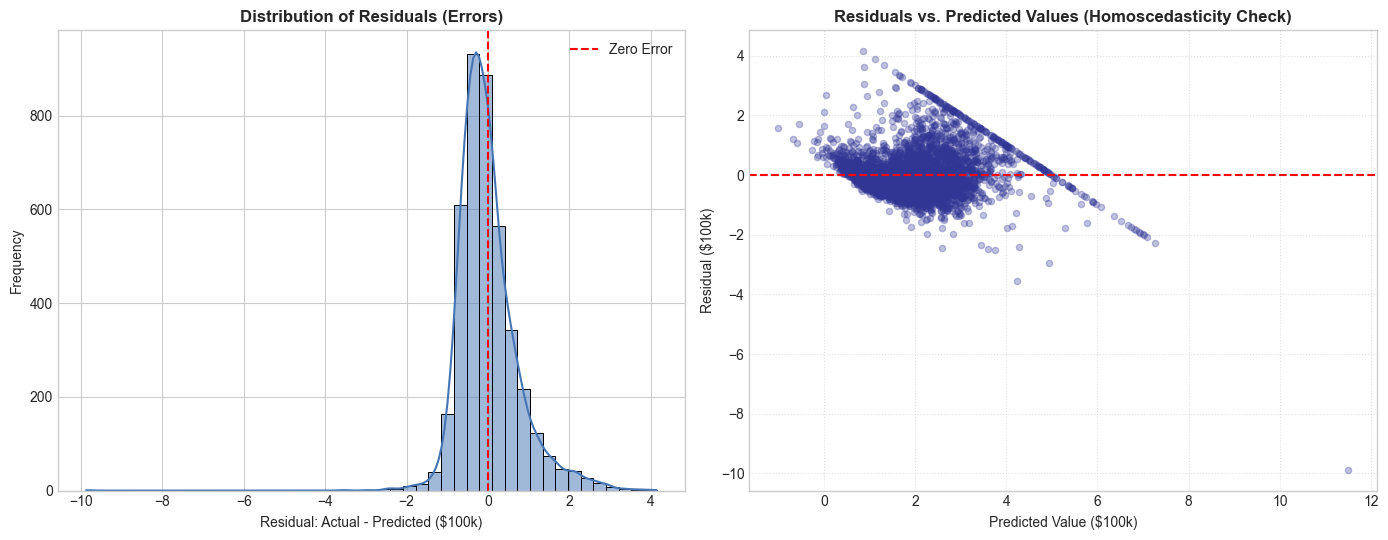

In [12]:
# 2. Residual Distribution & Residuals vs Predicted
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Residuals Histogram & KDE
sns.histplot(residuals, kde=True, color='#4575b4', ax=ax1, bins=45)
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
ax1.set_title("Distribution of Residuals (Errors)", fontweight='bold')
ax1.set_xlabel("Residual: Actual - Predicted ($100k)")
ax1.set_ylabel("Frequency")
ax1.legend()

# Residuals vs Predicted Values
ax2.scatter(y_pred, residuals, alpha=0.3, color='#313695', s=20)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_title("Residuals vs. Predicted Values (Homoscedasticity Check)", fontweight='bold')
ax2.set_xlabel("Predicted Value ($100k)")
ax2.set_ylabel("Residual ($100k)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


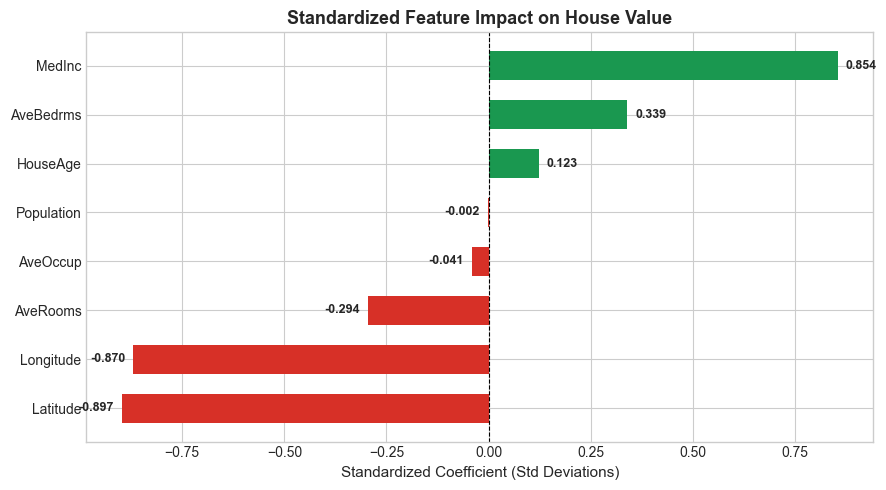

In [13]:
# 3. Standardized Feature Importance
# Standardizing features allows direct comparison of relative feature contributions
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
pipeline.fit(X_train, y_train)

std_coefs = pd.Series(pipeline.named_steps['regressor'].coef_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
colors = ['#d73027' if c < 0 else '#1a9850' for c in std_coefs.values]
bars = plt.barh(std_coefs.index, std_coefs.values, color=colors, height=0.6)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Standardized Coefficient (Std Deviations)", fontsize=11)
plt.title("Standardized Feature Impact on House Value", fontsize=13, fontweight='bold')

for bar in bars:
    w = bar.get_width()
    ha = 'left' if w >= 0 else 'right'
    offset = 0.02 if w >= 0 else -0.02
    plt.text(w + offset, bar.get_y() + bar.get_height()/2, f"{w:.3f}",
             va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### 9. Model Serialization & Test Inference
We persist the trained model pipeline to `models/linear_regression_model.pkl` using `joblib` so it can be deployed into our Streamlit prediction application.

In [14]:
# Save the model artifact
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "linear_regression_model.pkl")

bundle = {
    'model': model,
    'pipeline': pipeline,
    'feature_names': list(X.columns),
    'metrics': {
        'MAE': float(mae),
        'RMSE': float(rmse),
        'R2': float(r2_test)
    }
}
joblib.dump(bundle, model_path)
print(f"Model successfully saved to: {model_path}")

# Verify reloading and perform a sample prediction
loaded_bundle = joblib.load(model_path)
sample_input = X_test.iloc[0:1]
sample_pred = loaded_bundle['model'].predict(sample_input)[0]
sample_actual = y_test.iloc[0]

print(f"\nSample Verification:")
print(f"Input features:\n{sample_input.to_dict(orient='records')[0]}")
print(f"Predicted Price : ${sample_pred * 100000:,.2f} ({sample_pred:.3f} in $100k)")
print(f"Actual Price    : ${sample_actual * 100000:,.2f} ({sample_actual:.3f} in $100k)")


Model successfully saved to: models\linear_regression_model.pkl

Sample Verification:
Input features:
{'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}
Predicted Price : $71,912.28 (0.719 in $100k)
Actual Price    : $47,700.00 (0.477 in $100k)


### 10. Summary & Future Recommendations

#### Observations
1. **Baseline Fit**: The Linear Regression model explains **57.58%** of the variance in California housing prices ($R^2 = 0.5758$) with an RMSE of **$74,558**.
2. **Key Determinant**: Median Income (`MedInc`) is overwhelmingly the strongest positive contributor (+0.854 std coef).
3. **Ceiling Distortion**: The 5.0 ($500,000) target truncation creates noticeable residual bias at higher price ranges.
4. **Multicollinearity**: `AveRooms` and `AveBedrms` exhibit strong collinearity ($r = 0.85$), which introduces negative coefficients on `AveRooms` when combined with `AveBedrms`.

#### Actionable Improvements
* **Feature Engineering**: Compute house density metrics and distance to the nearest Pacific coast or major metropolitan centers (San Francisco, Los Angeles).
* **Regularization**: Utilize Ridge or ElasticNet regression to handle multicollinearity between room features.
* **Non-Linear Ensembles**: Transition to tree-based ensemble models such as **Random Forest**, **LightGBM**, or **XGBoost**, which routinely achieve $R^2 > 0.80$ on this dataset by learning non-linear geospatial boundary surfaces.
